In [3]:
#lab 3 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint

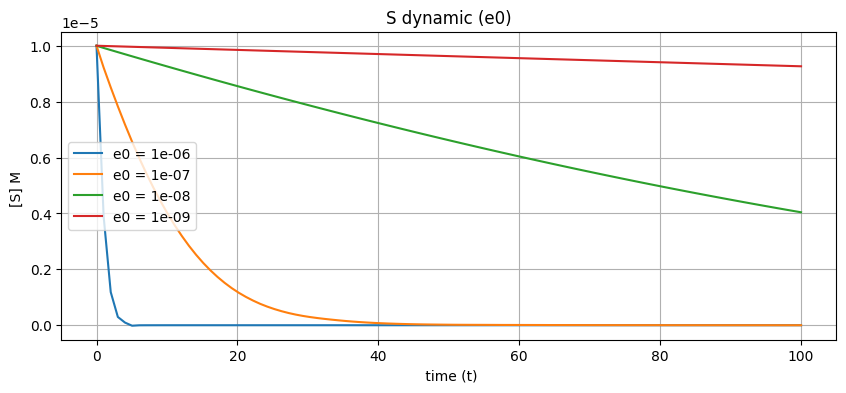

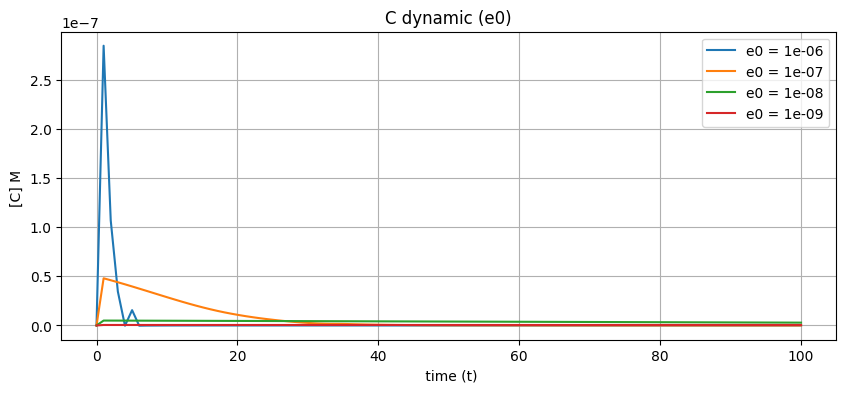

In [64]:
#Params 
k1= 4e+6 #M-1 s_1
k_1= 25 #s-1
k2= 15 #s-1
e0 = [1e-6, 1e-7, 1e-8, 1e-9] #M 

def cinetic_2_states(y,t, e0):
    s, c = y
    dsdt= k_1*c - k1*s*(e0-c)
    dcdt = k1*s*(e0-c) - (k_1 + k2)*c
    return [dsdt, dcdt]

km= 1e-5 
s0 = km
c0 = 0
t = np.linspace(0, 100, 100)
y0 = [s0, c0]


plt.figure(figsize=(10,4 ))

s_list = []
c_list = []

for i in e0:
    solution = odeint( cinetic_2_states, y0, t, args =(i,))
    s = solution[:, 0]
    s_list.append(s)  # Aggiungi la lista di s per questo e0 a s_list
    plt.plot (t, s, label = f'e0 = {i}')
    plt.title ("S dynamic (e0)")
    plt.xlabel (" time (t)")
    plt.ylabel ("[S] M ")
    plt.grid(True)
    plt.legend()
plt.show()

plt.figure(figsize=(10,4 ))
for i in e0:
    solution = odeint( cinetic_2_states, y0, t, args =(i,))
    c = solution[:, 1]
    c_list.append(c)
    plt.plot (t, c, label = f'e0 = {i}')
    plt.title ("C dynamic (e0)")
    plt.xlabel (" time (t)")
    plt.ylabel ("[C] M ")
    plt.grid(True)
    plt.legend()
plt.show()


In [65]:
#Slow vs Fast Time constant #tempo a cui raggiungo i 2/3 del valore max 

for i in e0:
    tau_s = 1/ (k1*(i-c0)) #for t<< dymanic can be approximate by dsdt eq
    tau_c = 1/ k1*s0

    print(f"Slow Time constant for e0={i}: {tau_s}")
    print(f"Fast Time constant for e0={i}: {tau_c}")


Slow Time constant for e0=1e-06: 0.25
Fast Time constant for e0=1e-06: 2.5000000000000003e-12
Slow Time constant for e0=1e-07: 2.5
Fast Time constant for e0=1e-07: 2.5000000000000003e-12
Slow Time constant for e0=1e-08: 25.0
Fast Time constant for e0=1e-08: 2.5000000000000003e-12
Slow Time constant for e0=1e-09: 250.0
Fast Time constant for e0=1e-09: 2.5000000000000003e-12


In [66]:
#Uniform Approximation

def uniform_app(su, t, e0):
    dsudt = - (k2*e0*su)/(km + su)
    dcudt = (e0*su)/ (km + su) - (e0*s0) / (km +s0)*np.exp(-(km+s0)*k1*t)
    return np.array([dsudt]).ravel()

#Params 
su0 = s0

s_uniform_list = []
c_uniform_list = []

for i in e0:
    sol_uniform = odeint( uniform_app, su0, t, args= (i,)).flatten()
    su = sol_uniform
    cu = (i*su)/ (km + su) - (i*s0) / (km +s0)*np.exp(-(km+s0)*k1*t)

    s_uniform_list.append(su)
    c_uniform_list.append(cu)

    #print ("Substrate with Uniform Approximation:" , f'{i}', sol_uniform)
    #print ("Complex with Uniform Approximation:", f'{i}', cu)

C:\Users\bulga\AppData\Local\Temp\ipykernel_6732\813933914.py:5: RuntimeWarning: invalid value encountered in divide
  err_c = np.abs(c_list [i] - c_uniform_list[i])/ np.abs(c_list[i])


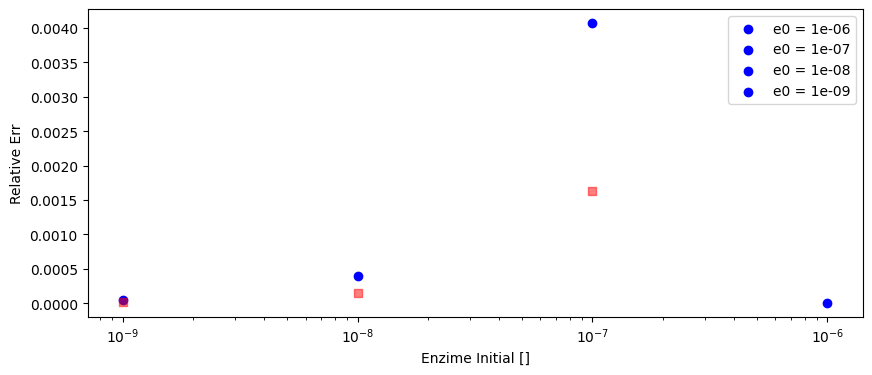

In [112]:
#Error over e0 value 
plt.figure(figsize=(10,4 ))
for i in range(4):
    err_s = np.abs( s_list [i]- s_uniform_list[i])/ np.abs(s_list[i])
    err_c = np.abs(c_list [i] - c_uniform_list[i])/ np.abs(c_list[i])
    
    plt.scatter(e0[i], err_s[i], label=f'e0 = {e0[i]}', color= "blue")
    plt.scatter(e0[i], err_c[i], marker= 's', color= "red",  alpha= 0.5)

    plt.ylabel("Relative Err")
    plt.xlabel("Enzime Initial []")
    plt.xscale("log")
    plt.legend()

#print ("Error on s:", err_s)
#print ("Error on c:", err_c)



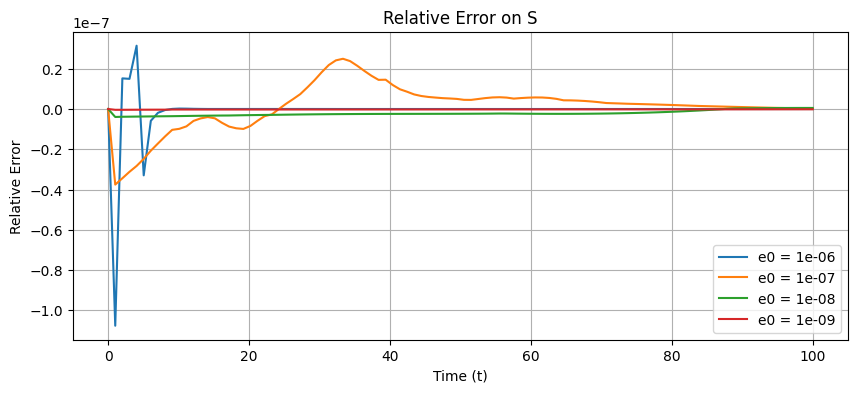

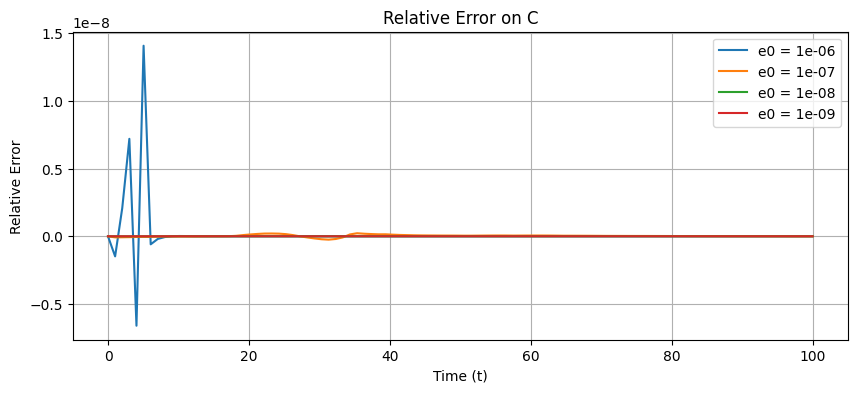

In [126]:
plt.figure(figsize=(10,4 ))
for i in range (4):
    err_s = s_list[i]- s_uniform_list[i]
    plt.plot(t,err_s, label= f'e0 = {e0[i]}')
    plt.xlabel("Time (t)")
    plt.ylabel("Relative Error")
    plt.legend()
    plt.title("Relative Error on S")
    plt.grid(True)


plt.figure(figsize=(10,4 ))
for i in range (4):
    err_c = c_list[i]- c_uniform_list[i]
    plt.plot(t,err_c, label= f'e0 = {e0[i]}')
    plt.xlabel("Time (t)")
    plt.ylabel("Relative Error")
    plt.legend()
    plt.title("Relative Error on C")
    plt.grid(True)